# NB-04A — Universo S&P 500 e indicadores técnicos base

## Propósito

Este notebook se construye como capa de datos e indicadores para extender el motor técnico desarrollado antes al universo S&P 500.

Este notebook **no decide entradas**, **no decide salidas** y **no calcula rentabilidad**. Su único objetivo es producir un dataset técnico consistente, auditado y reutilizable mas adelante.

## DE NB-02/NB-03

La parametrización base de Ichimoku queda fijada en:

| Componente | Valor |
|---|---:|
| Tenkan | 7 |
| Kijun | 22 |
| Senkou B | 44 |
| Shift visual | 22 |

El dataset generado debe incluir como mínimo:

- OHLCV ajustado.
- Ichimoku 7/22/44.
- Kumo superior/inferior.
- Estado de nube alcista/bajista.
- Tenkan/Kijun y cruces.
- Heiken Ashi.
- SMA5.
- Estocástico.
- ATR.
- RSI.
- MACD.
- Volumen relativo.
- Liquidez en dólares.

## Principio metodológico

Las reglas de entrada y salida se aplicarán posteriormente:

- **NB-04B:** detección de eventos técnicos equivalentes a los hallazgos del NB-03.
- **NB-04C:** backtest de cartera con lógica Core50/Táctico50.

Por tanto, este notebook debe ser tratado como **ingeniería de datos**, no como backtest.

In [1]:
# ============================================================
# 1 — CONFIGURACIÓN GENERAL NB-04A
# ============================================================

from pathlib import Path
from datetime import datetime
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Fechas de análisis
START_DATE = "2018-01-01"
END_DATE = None  # None = hasta la fecha disponible en yfinance

# Universo
USE_WIKIPEDIA_SP500 = True
CUSTOM_TICKERS = None  # Ejemplo: ["AAPL", "MSFT", "NVDA"] para pruebas rápidas

# Descarga
BATCH_SIZE = 50
USE_LOCAL_CACHE_IF_EXISTS = True
FORCE_REDOWNLOAD = False

# Ichimoku validado en NB-02B/NB-02D
ICHIMOKU_TENKAN = 7
ICHIMOKU_KIJUN = 22
ICHIMOKU_SENKOU_B = 44
ICHIMOKU_SHIFT_VISUAL = 22

# Indicadores auxiliares
SMA_SHORT = 5
VOLUME_WINDOW = 20
ATR_WINDOW = 14
RSI_WINDOW = 14
STOCH_WINDOW = 14
STOCH_SMOOTH_D = 3
MACD_FAST = 12
MACD_SLOW = 26
MACD_SIGNAL = 9

# Warmup metodológico para auditoría posterior
# Se conserva el histórico completo, pero se marca qué filas son operativas.
WARMUP_ROWS = 70

# Liquidez: se calcula en 04A, pero el umbral final de uso se decide en 04B.
MIN_DOLLAR_VOLUME_DEFAULT = 10_000_000

# Rutas
OUTPUT_DIR = Path("outputs_nb04a_sp500_indicators")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE_PATH = OUTPUT_DIR / "sp500_ohlcv_raw_adjusted.csv"
INDICATORS_CSV_PATH = OUTPUT_DIR / "sp500_indicators_ichimoku_7_22_44.csv"
INDICATORS_PARQUET_PATH = OUTPUT_DIR / "sp500_indicators_ichimoku_7_22_44.parquet"
TICKERS_PATH = OUTPUT_DIR / "sp500_tickers_used.csv"
SUMMARY_PATH = OUTPUT_DIR / "summary_nb04a.json"
QUALITY_PATH = OUTPUT_DIR / "quality_manifest_nb04a.csv"
NULLS_PATH = OUTPUT_DIR / "nulls_post_warmup_nb04a.csv"

config_nb04a = {
    "START_DATE": START_DATE,
    "END_DATE": END_DATE,
    "ICHIMOKU_TENKAN": ICHIMOKU_TENKAN,
    "ICHIMOKU_KIJUN": ICHIMOKU_KIJUN,
    "ICHIMOKU_SENKOU_B": ICHIMOKU_SENKOU_B,
    "ICHIMOKU_SHIFT_VISUAL": ICHIMOKU_SHIFT_VISUAL,
    "SMA_SHORT": SMA_SHORT,
    "VOLUME_WINDOW": VOLUME_WINDOW,
    "ATR_WINDOW": ATR_WINDOW,
    "RSI_WINDOW": RSI_WINDOW,
    "STOCH_WINDOW": STOCH_WINDOW,
    "STOCH_SMOOTH_D": STOCH_SMOOTH_D,
    "MACD_FAST": MACD_FAST,
    "MACD_SLOW": MACD_SLOW,
    "MACD_SIGNAL": MACD_SIGNAL,
    "WARMUP_ROWS": WARMUP_ROWS,
    "MIN_DOLLAR_VOLUME_DEFAULT": MIN_DOLLAR_VOLUME_DEFAULT,
}

print("Configuración NB-04A")
print("=" * 80)
for k, v in config_nb04a.items():
    print(f"{k}: {v}")
print("\nDirectorio de salida:", OUTPUT_DIR.resolve())

Configuración NB-04A
START_DATE: 2018-01-01
END_DATE: None
ICHIMOKU_TENKAN: 7
ICHIMOKU_KIJUN: 22
ICHIMOKU_SENKOU_B: 44
ICHIMOKU_SHIFT_VISUAL: 22
SMA_SHORT: 5
VOLUME_WINDOW: 20
ATR_WINDOW: 14
RSI_WINDOW: 14
STOCH_WINDOW: 14
STOCH_SMOOTH_D: 3
MACD_FAST: 12
MACD_SLOW: 26
MACD_SIGNAL: 9
WARMUP_ROWS: 70
MIN_DOLLAR_VOLUME_DEFAULT: 10000000

Directorio de salida: /Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators


## 2. Librerías y utilidades de descarga

Esta sección resuelve tres problemas prácticos:

1. Obtener la lista de componentes del S&P 500.
2. Normalizar símbolos para `yfinance` (`BRK.B` → `BRK-B`).
3. Descargar precios en lotes para evitar errores por volumen de consulta.

In [2]:
# ============================================================
# 2 — UTILIDADES DE UNIVERSO Y DESCARGA
# ============================================================

import requests
from io import StringIO

try:
    import yfinance as yf
except ImportError as e:
    raise ImportError(
        "Falta yfinance. Instala con: pip install yfinance"
    ) from e


def normalize_ticker_for_yfinance(symbol: str) -> str:
    """Convierte símbolos tipo BRK.B/BF.B al formato usado por yfinance."""
    return str(symbol).strip().replace(".", "-")


def get_sp500_tickers_from_local_or_wikipedia() -> list:
    """Obtiene tickers desde archivo local si existe; si no, usa Wikipedia con User-Agent."""
    local_candidates = [
        Path("sp500_tickers.csv"),
        Path("data/sp500_tickers.csv"),
        Path("data_sp500/sp500_tickers.csv"),
        OUTPUT_DIR / "sp500_tickers_used.csv",
    ]

    for path in local_candidates:
        if path.exists():
            df_local = pd.read_csv(path)
            col = None
            for candidate in ["Ticker", "Symbol", "ticker", "symbol"]:
                if candidate in df_local.columns:
                    col = candidate
                    break
            if col is None:
                raise ValueError(f"Archivo local {path} no tiene columna Ticker/Symbol.")
            tickers = (
                df_local[col]
                .dropna()
                .astype(str)
                .map(normalize_ticker_for_yfinance)
                .drop_duplicates()
                .sort_values()
                .tolist()
            )
            print(f"Tickers cargados desde archivo local: {path} ({len(tickers)})")
            return tickers

    if not USE_WIKIPEDIA_SP500:
        raise FileNotFoundError(
            "No encontré archivo local de tickers y USE_WIKIPEDIA_SP500=False."
        )

    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.0 Safari/605.1.15"
        )
    }

    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    tables = pd.read_html(StringIO(response.text))

    table = None
    for t in tables:
        if "Symbol" in t.columns:
            table = t.copy()
            break

    if table is None:
        raise RuntimeError("No se encontró una tabla con columna 'Symbol' en Wikipedia.")

    tickers = (
        table["Symbol"]
        .dropna()
        .astype(str)
        .map(normalize_ticker_for_yfinance)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    pd.DataFrame({"Ticker": tickers}).to_csv(TICKERS_PATH, index=False)
    print(f"Tickers descargados desde Wikipedia: {len(tickers)}")
    print(f"Lista guardada en: {TICKERS_PATH}")
    return tickers


def chunk_list(items, batch_size):
    for i in range(0, len(items), batch_size):
        yield items[i:i + batch_size]


def normalize_yfinance_batch(raw: pd.DataFrame, tickers_batch: list) -> pd.DataFrame:
    """Convierte la respuesta de yfinance a formato largo: Date, Ticker, OHLCV."""
    rows = []

    if raw is None or raw.empty:
        return pd.DataFrame()

    if isinstance(raw.columns, pd.MultiIndex):
        level0 = list(raw.columns.get_level_values(0).unique())
        level1 = list(raw.columns.get_level_values(1).unique())

        # Caso group_by='ticker': nivel 0 = ticker
        if any(t in level0 for t in tickers_batch):
            for ticker in tickers_batch:
                if ticker not in raw.columns.get_level_values(0):
                    continue
                df_t = raw[ticker].copy()
                df_t["Ticker"] = ticker
                rows.append(df_t.reset_index())
        # Caso group_by='column': nivel 1 = ticker
        elif any(t in level1 for t in tickers_batch):
            for ticker in tickers_batch:
                if ticker not in raw.columns.get_level_values(1):
                    continue
                df_t = raw.xs(ticker, level=1, axis=1).copy()
                df_t["Ticker"] = ticker
                rows.append(df_t.reset_index())
        else:
            return pd.DataFrame()
    else:
        # Caso un solo ticker
        ticker = tickers_batch[0]
        df_t = raw.copy()
        df_t["Ticker"] = ticker
        rows.append(df_t.reset_index())

    if not rows:
        return pd.DataFrame()

    df_long = pd.concat(rows, ignore_index=True)

    # Normalización de nombres esperados
    rename_map = {
        "Adj Close": "Adj_Close",
        "Date": "Date",
        "Open": "Open",
        "High": "High",
        "Low": "Low",
        "Close": "Close",
        "Volume": "Volume",
    }
    df_long = df_long.rename(columns=rename_map)

    required = ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]
    for col in required:
        if col not in df_long.columns:
            df_long[col] = np.nan

    if "Adj_Close" not in df_long.columns:
        df_long["Adj_Close"] = df_long["Close"]

    df_long = df_long[["Date", "Ticker", "Open", "High", "Low", "Close", "Adj_Close", "Volume"]]
    df_long["Date"] = pd.to_datetime(df_long["Date"]).dt.tz_localize(None)

    return df_long


def download_ohlcv_yfinance(tickers: list) -> pd.DataFrame:
    """Descarga OHLCV diario para los tickers indicados usando yfinance en lotes."""
    all_batches = []
    failed_batches = []

    for idx, batch in enumerate(chunk_list(tickers, BATCH_SIZE), start=1):
        print(f"Descargando lote {idx}: {len(batch)} tickers")
        try:
            raw = yf.download(
                tickers=batch,
                start=START_DATE,
                end=END_DATE,
                auto_adjust=False,
                group_by="ticker",
                progress=False,
                threads=True,
                actions=False,
            )
            df_batch = normalize_yfinance_batch(raw, batch)
            if len(df_batch) == 0:
                failed_batches.append(batch)
            else:
                all_batches.append(df_batch)
        except Exception as e:
            print(f"Error en lote {idx}: {e}")
            failed_batches.append(batch)

    if not all_batches:
        raise RuntimeError("No se pudo descargar ningún dato desde yfinance.")

    df_raw = pd.concat(all_batches, ignore_index=True)
    df_raw = df_raw.dropna(subset=["Date", "Ticker"]).copy()
    df_raw = df_raw.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    if failed_batches:
        failed_flat = [t for batch in failed_batches for t in batch]
        failed_path = OUTPUT_DIR / "failed_ticker_batches.csv"
        pd.DataFrame({"Ticker": failed_flat}).to_csv(failed_path, index=False)
        print(f"Advertencia: algunos tickers/lotes fallaron. Ver: {failed_path}")

    return df_raw

## 3. Carga o descarga de datos OHLCV

Si existe un caché local, se reutiliza para evitar descargas innecesarias. Si no existe, se descarga desde `yfinance`.

In [3]:
# ============================================================
# 3 — CARGA O DESCARGA DE OHLCV
# ============================================================

if CUSTOM_TICKERS is not None:
    tickers = [normalize_ticker_for_yfinance(t) for t in CUSTOM_TICKERS]
else:
    tickers = get_sp500_tickers_from_local_or_wikipedia()

print("Tickers a procesar:", len(tickers))
print(tickers[:20])

if RAW_CACHE_PATH.exists() and USE_LOCAL_CACHE_IF_EXISTS and not FORCE_REDOWNLOAD:
    print(f"Cargando OHLCV desde caché local: {RAW_CACHE_PATH}")
    df_raw = pd.read_csv(RAW_CACHE_PATH, parse_dates=["Date"])
else:
    print("Descargando OHLCV desde yfinance...")
    df_raw = download_ohlcv_yfinance(tickers)
    df_raw.to_csv(RAW_CACHE_PATH, index=False)
    print(f"OHLCV guardado en caché: {RAW_CACHE_PATH}")

print("Dataset OHLCV crudo:", df_raw.shape)
display(df_raw.head())
display(df_raw.tail())

Tickers descargados desde Wikipedia: 503
Lista guardada en: outputs_nb04a_sp500_indicators/sp500_tickers_used.csv
Tickers a procesar: 503
['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM']
Descargando OHLCV desde yfinance...
Descargando lote 1: 50 tickers
Descargando lote 2: 50 tickers
Descargando lote 3: 50 tickers
Descargando lote 4: 50 tickers
Descargando lote 5: 50 tickers
Descargando lote 6: 50 tickers
Descargando lote 7: 50 tickers
Descargando lote 8: 50 tickers
Descargando lote 9: 50 tickers
Descargando lote 10: 50 tickers
Descargando lote 11: 3 tickers
OHLCV guardado en caché: outputs_nb04a_sp500_indicators/sp500_ohlcv_raw_adjusted.csv
Dataset OHLCV crudo: (1059318, 8)


Price,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2018-01-02,A,67.419998,67.889999,67.339996,67.599998,63.522770,1047800.0
1,2018-01-03,A,67.620003,69.489998,67.599998,69.320000,65.139030,1698900.0
2,2018-01-04,A,69.540001,69.820000,68.779999,68.800003,64.650383,2230700.0
3,2018-01-05,A,68.730003,70.099998,68.730003,69.900002,65.684044,1632500.0
4,2018-01-08,A,69.730003,70.330002,69.550003,70.050003,65.825005,1613400.0


Price,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
1059313,2026-05-13,ZTS,76.680000,77.839996,74.290001,74.339996,74.339996,13085600.0
1059314,2026-05-14,ZTS,74.449997,75.750000,73.980003,75.480003,75.480003,8714800.0
1059315,2026-05-15,ZTS,75.400002,76.900002,72.379997,74.220001,74.220001,8952000.0
1059316,2026-05-18,ZTS,74.199997,77.959999,74.199997,77.720001,77.720001,8843100.0
1059317,2026-05-19,ZTS,79.849998,80.360001,77.593002,78.065002,78.065002,3971855.0


## 4. Ajuste de OHLC y validación básica

Se construyen columnas ajustadas para que los indicadores no queden distorsionados por splits/dividendos:

- `Open_Adj`
- `High_Adj`
- `Low_Adj`
- `Close_Adj`

La regla general es usar el factor `Adj_Close / Close`. Si no existe `Adj_Close`, se usa `Close` como precio ajustado.

In [4]:
# ============================================================
# 4 — OHLC AJUSTADO Y VALIDACIÓN BÁSICA
# ============================================================

def add_adjusted_ohlc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    numeric_cols = ["Open", "High", "Low", "Close", "Adj_Close", "Volume"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Evitar divisiones inválidas
    adj_factor = np.where(
        (df["Close"].notna()) & (df["Close"] != 0) & df["Adj_Close"].notna(),
        df["Adj_Close"] / df["Close"],
        1.0,
    )
    df["Adj_Factor"] = adj_factor

    df["Open_Adj"] = df["Open"] * df["Adj_Factor"]
    df["High_Adj"] = df["High"] * df["Adj_Factor"]
    df["Low_Adj"] = df["Low"] * df["Adj_Factor"]
    df["Close_Adj"] = np.where(df["Adj_Close"].notna(), df["Adj_Close"], df["Close"])

    # Limpieza mínima
    df = df.dropna(subset=["Date", "Ticker", "Open_Adj", "High_Adj", "Low_Adj", "Close_Adj"]).copy()
    df = df[df["Volume"].fillna(0) >= 0].copy()
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    return df


df_prices = add_adjusted_ohlc(df_raw)

print("Dataset OHLC ajustado:", df_prices.shape)
print("Tickers con datos:", df_prices["Ticker"].nunique())
print("Fecha mínima:", df_prices["Date"].min())
print("Fecha máxima:", df_prices["Date"].max())

display(df_prices.head())

Dataset OHLC ajustado: (1037988, 13)
Tickers con datos: 503
Fecha mínima: 2018-01-02 00:00:00
Fecha máxima: 2026-05-19 00:00:00


Price,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume,Adj_Factor,Open_Adj,High_Adj,Low_Adj,Close_Adj
0,2018-01-02,A,67.419998,67.889999,67.339996,67.599998,63.522770,1047800.0,0.939686,63.353626,63.795280,63.278450,63.522770
1,2018-01-03,A,67.620003,69.489998,67.599998,69.320000,65.139030,1698900.0,0.939686,63.541567,65.298775,63.522769,65.139030
2,2018-01-04,A,69.540001,69.820000,68.779999,68.800003,64.650383,2230700.0,0.939686,65.345748,65.608859,64.631585,64.650383
3,2018-01-05,A,68.730003,70.099998,68.730003,69.900002,65.684044,1632500.0,0.939686,64.584613,65.871978,64.584613,65.684044
4,2018-01-08,A,69.730003,70.330002,69.550003,70.050003,65.825005,1613400.0,0.939686,65.524305,66.088116,65.355162,65.825005


## 5. Cálculo de indicadores técnicos

Esta sección calcula los indicadores base. No se genera ninguna decisión de trading; solo se crean variables observables que luego se podrán combinar.

In [5]:
# ============================================================
# 5 — FUNCIONES DE INDICADORES
# ============================================================

def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, min_periods=window, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_heiken_ashi_for_ticker(df_t: pd.DataFrame) -> pd.DataFrame:
    df_t = df_t.copy().sort_values("Date")
    ha_close = (df_t["Open_Adj"] + df_t["High_Adj"] + df_t["Low_Adj"] + df_t["Close_Adj"]) / 4
    ha_open = np.zeros(len(df_t), dtype=float)

    if len(df_t) > 0:
        ha_open[0] = (df_t["Open_Adj"].iloc[0] + df_t["Close_Adj"].iloc[0]) / 2
        for i in range(1, len(df_t)):
            ha_open[i] = (ha_open[i-1] + ha_close.iloc[i-1]) / 2

    df_t["HA_Open"] = ha_open
    df_t["HA_Close"] = ha_close.values
    df_t["HA_High"] = np.maximum.reduce([df_t["High_Adj"].values, df_t["HA_Open"].values, df_t["HA_Close"].values])
    df_t["HA_Low"] = np.minimum.reduce([df_t["Low_Adj"].values, df_t["HA_Open"].values, df_t["HA_Close"].values])
    df_t["HA_Body"] = (df_t["HA_Close"] - df_t["HA_Open"]).abs()
    df_t["HA_Bullish"] = df_t["HA_Close"] > df_t["HA_Open"]
    df_t["HA_Bearish"] = df_t["HA_Close"] < df_t["HA_Open"]
    df_t["HA2_Bullish"] = df_t["HA_Bullish"] & df_t["HA_Bullish"].shift(1).fillna(False)
    df_t["HA2_Bearish"] = df_t["HA_Bearish"] & df_t["HA_Bearish"].shift(1).fillna(False)
    return df_t


def compute_indicators_for_ticker(df_t: pd.DataFrame) -> pd.DataFrame:
    df_t = df_t.copy().sort_values("Date")

    high = df_t["High_Adj"]
    low = df_t["Low_Adj"]
    close = df_t["Close_Adj"]
    volume = df_t["Volume"]

    # ----------------------------
    # Ichimoku 7/22/44 sin desplazamiento lógico
    # ----------------------------
    tenkan_high = high.rolling(ICHIMOKU_TENKAN, min_periods=ICHIMOKU_TENKAN).max()
    tenkan_low = low.rolling(ICHIMOKU_TENKAN, min_periods=ICHIMOKU_TENKAN).min()
    kijun_high = high.rolling(ICHIMOKU_KIJUN, min_periods=ICHIMOKU_KIJUN).max()
    kijun_low = low.rolling(ICHIMOKU_KIJUN, min_periods=ICHIMOKU_KIJUN).min()
    senkou_b_high = high.rolling(ICHIMOKU_SENKOU_B, min_periods=ICHIMOKU_SENKOU_B).max()
    senkou_b_low = low.rolling(ICHIMOKU_SENKOU_B, min_periods=ICHIMOKU_SENKOU_B).min()

    df_t["Ichimoku_Tenkan"] = (tenkan_high + tenkan_low) / 2
    df_t["Ichimoku_Kijun"] = (kijun_high + kijun_low) / 2
    df_t["Ichimoku_Senkou_A"] = (df_t["Ichimoku_Tenkan"] + df_t["Ichimoku_Kijun"]) / 2
    df_t["Ichimoku_Senkou_B"] = (senkou_b_high + senkou_b_low) / 2
    df_t["Kumo_Top"] = df_t[["Ichimoku_Senkou_A", "Ichimoku_Senkou_B"]].max(axis=1)
    df_t["Kumo_Bottom"] = df_t[["Ichimoku_Senkou_A", "Ichimoku_Senkou_B"]].min(axis=1)

    # Series solo para visualización tipo TradingView. No usar para decisión en 04B.
    df_t["Ichimoku_Senkou_A_Visual"] = df_t["Ichimoku_Senkou_A"].shift(ICHIMOKU_SHIFT_VISUAL)
    df_t["Ichimoku_Senkou_B_Visual"] = df_t["Ichimoku_Senkou_B"].shift(ICHIMOKU_SHIFT_VISUAL)

    # Estados primarios, no señales finales
    df_t["price_above_kumo"] = close > df_t["Kumo_Top"]
    df_t["price_below_kumo"] = close < df_t["Kumo_Bottom"]
    df_t["price_inside_kumo"] = (~df_t["price_above_kumo"]) & (~df_t["price_below_kumo"])
    df_t["kumo_bullish"] = df_t["Ichimoku_Senkou_A"] > df_t["Ichimoku_Senkou_B"]
    df_t["tenkan_above_kijun"] = df_t["Ichimoku_Tenkan"] > df_t["Ichimoku_Kijun"]
    df_t["close_above_tenkan"] = close > df_t["Ichimoku_Tenkan"]
    df_t["close_above_kijun"] = close > df_t["Ichimoku_Kijun"]
    df_t["tk_cross_up"] = (df_t["Ichimoku_Tenkan"] > df_t["Ichimoku_Kijun"]) & (df_t["Ichimoku_Tenkan"].shift(1) <= df_t["Ichimoku_Kijun"].shift(1))
    df_t["tk_cross_down"] = (df_t["Ichimoku_Tenkan"] < df_t["Ichimoku_Kijun"]) & (df_t["Ichimoku_Tenkan"].shift(1) >= df_t["Ichimoku_Kijun"].shift(1))
    df_t["kumo_breakout_up"] = (close > df_t["Kumo_Top"]) & (close.shift(1) <= df_t["Kumo_Top"].shift(1))
    df_t["kumo_breakdown_down"] = (close < df_t["Kumo_Bottom"]) & (close.shift(1) >= df_t["Kumo_Bottom"].shift(1))

    # ----------------------------
    # SMA5
    # ----------------------------
    df_t["SMA5"] = close.rolling(SMA_SHORT, min_periods=SMA_SHORT).mean()
    df_t["close_above_sma5"] = close > df_t["SMA5"]
    df_t["sma5_rising"] = df_t["SMA5"] > df_t["SMA5"].shift(1)

    # ----------------------------
    # Estocástico
    # ----------------------------
    lowest_low = low.rolling(STOCH_WINDOW, min_periods=STOCH_WINDOW).min()
    highest_high = high.rolling(STOCH_WINDOW, min_periods=STOCH_WINDOW).max()
    denom = (highest_high - lowest_low).replace(0, np.nan)
    df_t["Stoch_K"] = 100 * (close - lowest_low) / denom
    df_t["Stoch_D"] = df_t["Stoch_K"].rolling(STOCH_SMOOTH_D, min_periods=STOCH_SMOOTH_D).mean()
    df_t["stoch_cross_up"] = (df_t["Stoch_K"] > df_t["Stoch_D"]) & (df_t["Stoch_K"].shift(1) <= df_t["Stoch_D"].shift(1))
    df_t["stoch_cross_down"] = (df_t["Stoch_K"] < df_t["Stoch_D"]) & (df_t["Stoch_K"].shift(1) >= df_t["Stoch_D"].shift(1))
    df_t["stoch_bearish"] = df_t["Stoch_K"] < df_t["Stoch_D"]
    df_t["stoch_not_extreme_overbought"] = df_t["Stoch_K"] < 85

    # ----------------------------
    # ATR
    # ----------------------------
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    df_t["TR"] = tr
    df_t["ATR"] = tr.rolling(ATR_WINDOW, min_periods=ATR_WINDOW).mean()
    df_t["ATR_Pct"] = df_t["ATR"] / close

    # ----------------------------
    # RSI
    # ----------------------------
    df_t["RSI"] = compute_rsi(close, RSI_WINDOW)

    # ----------------------------
    # MACD
    # ----------------------------
    ema_fast = close.ewm(span=MACD_FAST, adjust=False, min_periods=MACD_FAST).mean()
    ema_slow = close.ewm(span=MACD_SLOW, adjust=False, min_periods=MACD_SLOW).mean()
    df_t["MACD"] = ema_fast - ema_slow
    df_t["MACD_Signal"] = df_t["MACD"].ewm(span=MACD_SIGNAL, adjust=False, min_periods=MACD_SIGNAL).mean()
    df_t["MACD_Hist"] = df_t["MACD"] - df_t["MACD_Signal"]
    df_t["macd_bullish"] = df_t["MACD"] > df_t["MACD_Signal"]
    df_t["macd_cross_up"] = (df_t["MACD"] > df_t["MACD_Signal"]) & (df_t["MACD"].shift(1) <= df_t["MACD_Signal"].shift(1))

    # ----------------------------
    # Volumen y liquidez
    # ----------------------------
    df_t["Volume_MA20"] = volume.rolling(VOLUME_WINDOW, min_periods=VOLUME_WINDOW).mean()
    df_t["Volume_Rel"] = volume / df_t["Volume_MA20"].replace(0, np.nan)
    df_t["volume_above_ma20"] = df_t["Volume_Rel"] >= 1.0
    df_t["Dollar_Volume"] = close * volume
    df_t["Dollar_Volume_MA20"] = df_t["Dollar_Volume"].rolling(VOLUME_WINDOW, min_periods=VOLUME_WINDOW).mean()
    df_t["liquidity_default_ok"] = df_t["Dollar_Volume_MA20"] >= MIN_DOLLAR_VOLUME_DEFAULT

    # ----------------------------
    # Helpers para Fibonacci posterior
    # ----------------------------
    df_t["Rolling_High_22"] = high.rolling(22, min_periods=22).max()
    df_t["Rolling_Low_22"] = low.rolling(22, min_periods=22).min()
    df_t["Rolling_High_44"] = high.rolling(44, min_periods=44).max()
    df_t["Rolling_Low_44"] = low.rolling(44, min_periods=44).min()

    # ----------------------------
    # Índice operativo por ticker
    # ----------------------------
    df_t["bar_index_ticker"] = np.arange(len(df_t))
    df_t["post_warmup"] = df_t["bar_index_ticker"] >= WARMUP_ROWS

    return df_t

In [6]:
# ============================================================
# 5B — EJECUCIÓN DEL CÁLCULO DE INDICADORES
# ============================================================

# Heiken Ashi primero porque es recursivo por ticker
df_ha = (
    df_prices
    .groupby("Ticker", group_keys=False)
    .apply(compute_heiken_ashi_for_ticker)
    .reset_index(drop=True)
)

# Resto de indicadores
df_indicators = (
    df_ha
    .groupby("Ticker", group_keys=False)
    .apply(compute_indicators_for_ticker)
    .reset_index(drop=True)
)

# Fila operativa mínima para NB-04B: no exige una señal, solo datos suficientes.
critical_cols = [
    "Close_Adj", "High_Adj", "Low_Adj", "Volume",
    "Ichimoku_Tenkan", "Ichimoku_Kijun", "Ichimoku_Senkou_A", "Ichimoku_Senkou_B",
    "Kumo_Top", "Kumo_Bottom",
    "SMA5", "Stoch_K", "Stoch_D", "ATR", "RSI",
    "Volume_Rel", "Dollar_Volume_MA20",
    "HA_Open", "HA_Close",
]

critical_cols = [c for c in critical_cols if c in df_indicators.columns]
df_indicators["row_operational_ok"] = df_indicators["post_warmup"] & df_indicators[critical_cols].notna().all(axis=1)

df_indicators = df_indicators.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Dataset de indicadores:", df_indicators.shape)
print("Tickers:", df_indicators["Ticker"].nunique())
print("Filas operativas:", int(df_indicators["row_operational_ok"].sum()))
print("% filas operativas:", f"{df_indicators['row_operational_ok'].mean():.2%}")

display(df_indicators.head())
display(df_indicators.tail())

Dataset de indicadores: (1037988, 72)
Tickers: 503
Filas operativas: 1002755
% filas operativas: 96.61%


Price,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume,Adj_Factor,Open_Adj,...,Dollar_Volume,Dollar_Volume_MA20,liquidity_default_ok,Rolling_High_22,Rolling_Low_22,Rolling_High_44,Rolling_Low_44,bar_index_ticker,post_warmup,row_operational_ok
0,2018-01-02,A,67.419998,67.889999,67.339996,67.599998,63.522770,1047800.0,0.939686,63.353626,...,6.655916e+07,NaN,False,NaN,NaN,NaN,NaN,0,False,False
1,2018-01-03,A,67.620003,69.489998,67.599998,69.320000,65.139030,1698900.0,0.939686,63.541567,...,1.106647e+08,NaN,False,NaN,NaN,NaN,NaN,1,False,False
2,2018-01-04,A,69.540001,69.820000,68.779999,68.800003,64.650383,2230700.0,0.939686,65.345748,...,1.442156e+08,NaN,False,NaN,NaN,NaN,NaN,2,False,False
3,2018-01-05,A,68.730003,70.099998,68.730003,69.900002,65.684044,1632500.0,0.939686,64.584613,...,1.072292e+08,NaN,False,NaN,NaN,NaN,NaN,3,False,False
4,2018-01-08,A,69.730003,70.330002,69.550003,70.050003,65.825005,1613400.0,0.939686,65.524305,...,1.062021e+08,NaN,False,NaN,NaN,NaN,NaN,4,False,False


Price,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume,Adj_Factor,Open_Adj,...,Dollar_Volume,Dollar_Volume_MA20,liquidity_default_ok,Rolling_High_22,Rolling_Low_22,Rolling_High_44,Rolling_Low_44,bar_index_ticker,post_warmup,row_operational_ok
1037983,2026-05-13,ZTS,76.680000,77.839996,74.290001,74.339996,74.339996,13085600.0,1.0,76.680000,...,9.727835e+08,7.179559e+08,True,123.32,74.290001,123.32,74.290001,2101,True,True
1037984,2026-05-14,ZTS,74.449997,75.750000,73.980003,75.480003,75.480003,8714800.0,1.0,74.449997,...,6.577931e+08,7.331303e+08,True,123.32,73.980003,123.32,73.980003,2102,True,True
1037985,2026-05-15,ZTS,75.400002,76.900002,72.379997,74.220001,74.220001,8952000.0,1.0,75.400002,...,6.644175e+08,7.287568e+08,True,123.32,72.379997,123.32,72.379997,2103,True,True
1037986,2026-05-18,ZTS,74.199997,77.959999,74.199997,77.720001,77.720001,8843100.0,1.0,74.199997,...,6.872857e+08,7.398135e+08,True,123.32,72.379997,123.32,72.379997,2104,True,True
1037987,2026-05-19,ZTS,79.849998,80.360001,77.593002,78.065002,78.065002,3971855.0,1.0,79.849998,...,3.100629e+08,7.332867e+08,True,123.32,72.379997,123.32,72.379997,2105,True,True


## 6. Auditoría de cobertura y calidad

Esta sección genera controles mínimos para validar si el dataset puede pasar a NB-04B.

Criterios esperados:

- número de tickers procesados razonable;
- rango temporal completo;
- suficientes filas post-warmup;
- nulos bajos en columnas críticas después de warmup;
- volumen/liquidez calculados;
- indicadores Ichimoku 7/22/44 presentes.

In [7]:
# ============================================================
# 6 — AUDITORÍA DE COBERTURA Y CALIDAD
# ============================================================

coverage = (
    df_indicators
    .groupby("Ticker")
    .agg(
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        n_rows=("Date", "count"),
        n_operational_rows=("row_operational_ok", "sum"),
        pct_operational=("row_operational_ok", "mean"),
        avg_dollar_volume_20=("Dollar_Volume_MA20", "mean"),
    )
    .reset_index()
    .sort_values(["n_operational_rows", "Ticker"], ascending=[True, True])
)

coverage["status"] = np.where(
    coverage["n_operational_rows"] > 0,
    "OK",
    "SIN_FILAS_OPERATIVAS"
)

post_warmup_df = df_indicators[df_indicators["post_warmup"]].copy()
nulls_post_warmup = (
    post_warmup_df[critical_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
nulls_post_warmup.columns = ["column", "pct_null_post_warmup"]

summary_nb04a = {
    "run_timestamp": datetime.now().isoformat(timespec="seconds"),
    "n_tickers_requested": len(tickers),
    "n_tickers_with_data": int(df_indicators["Ticker"].nunique()),
    "n_rows_total": int(len(df_indicators)),
    "n_rows_operational": int(df_indicators["row_operational_ok"].sum()),
    "pct_rows_operational": float(df_indicators["row_operational_ok"].mean()),
    "date_min": str(df_indicators["Date"].min().date()),
    "date_max": str(df_indicators["Date"].max().date()),
    "n_tickers_without_operational_rows": int((coverage["status"] != "OK").sum()),
    "ichimoku_config": "7/22/44_shift22_visual",
    "output_csv": str(INDICATORS_CSV_PATH),
    "output_parquet": str(INDICATORS_PARQUET_PATH),
}

print("Resumen NB-04A")
print("=" * 80)
for k, v in summary_nb04a.items():
    print(f"{k}: {v}")

print("\nTickers con menos filas operativas")
display(coverage.head(20))

print("\nNulos post-warmup en columnas críticas")
display(nulls_post_warmup)

Resumen NB-04A
run_timestamp: 2026-05-19T19:08:18
n_tickers_requested: 503
n_tickers_with_data: 503
n_rows_total: 1037988
n_rows_operational: 1002755
pct_rows_operational: 0.9660564476660617
date_min: 2018-01-02
date_max: 2026-05-19
n_tickers_without_operational_rows: 0
ichimoku_config: 7/22/44_shift22_visual
output_csv: outputs_nb04a_sp500_indicators/sp500_indicators_ichimoku_7_22_44.csv
output_parquet: outputs_nb04a_sp500_indicators/sp500_indicators_ichimoku_7_22_44.parquet

Tickers con menos filas operativas


,Ticker,first_date,last_date,n_rows,n_operational_rows,pct_operational,avg_dollar_volume_20,status
383,Q,2025-10-27,2026-05-19,141,71,0.503546,2.389649e+08,OK
408,SNDK,2025-02-13,2026-05-19,317,247,0.779180,4.199612e+09,OK
205,GEV,2024-03-27,2026-05-19,538,468,0.869888,1.402756e+09,OK
411,SOLV,2024-03-26,2026-05-19,539,469,0.870130,8.507007e+07,OK
468,VLTO,2023-10-04,2026-05-19,658,588,0.893617,1.529060e+08,OK
274,KVUE,2023-05-04,2026-05-19,763,693,0.908257,4.401815e+08,OK
203,GEHC,2022-12-15,2026-05-19,858,788,0.918415,2.546349e+08,OK
86,CEG,2022-01-19,2026-05-19,1087,1017,0.935603,5.277452e+08,OK
228,HOOD,2021-07-29,2026-05-19,1207,1137,0.942005,1.038642e+09,OK
39,APP,2021-04-15,2026-05-19,1280,1210,0.945312,9.199361e+08,OK



Nulos post-warmup en columnas críticas


,column,pct_null_post_warmup
0,Stoch_D,0.002294
1,Stoch_K,0.001496
2,Close_Adj,0.000000
3,SMA5,0.000000
4,HA_Open,0.000000
5,Dollar_Volume_MA20,0.000000
6,Volume_Rel,0.000000
7,RSI,0.000000
8,ATR,0.000000
9,Kumo_Bottom,0.000000


## 7. Validaciones visuales rápidas

Estas visualizaciones no son análisis de entrada/salida. Solo ayudan a comprobar si la descarga y los indicadores tienen sentido.

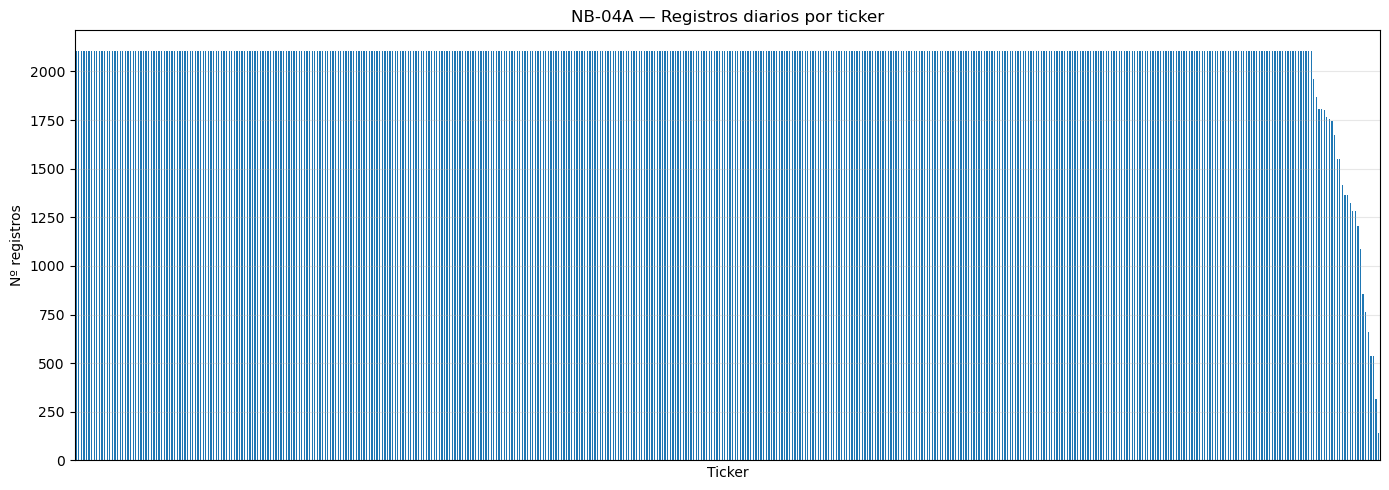

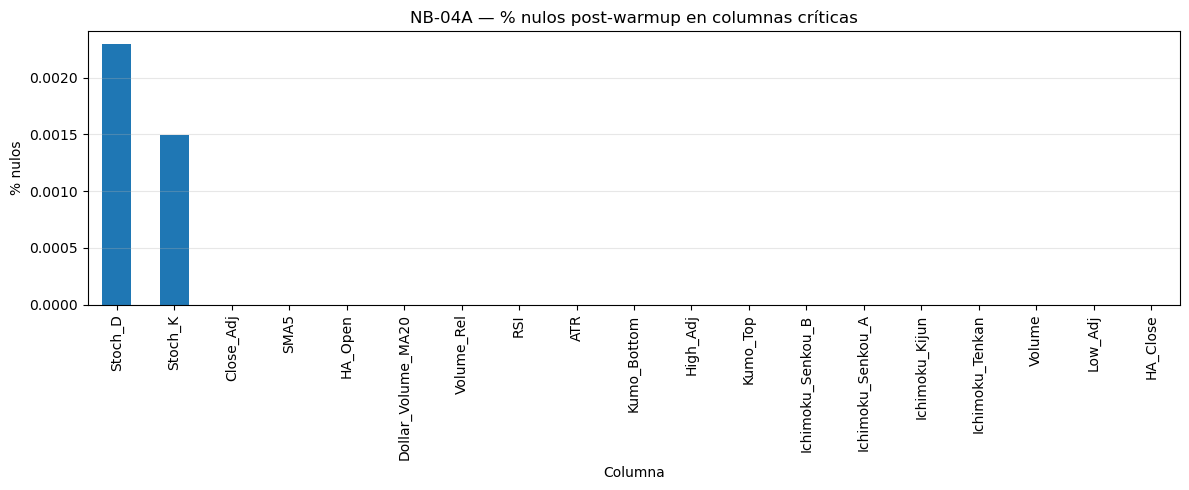

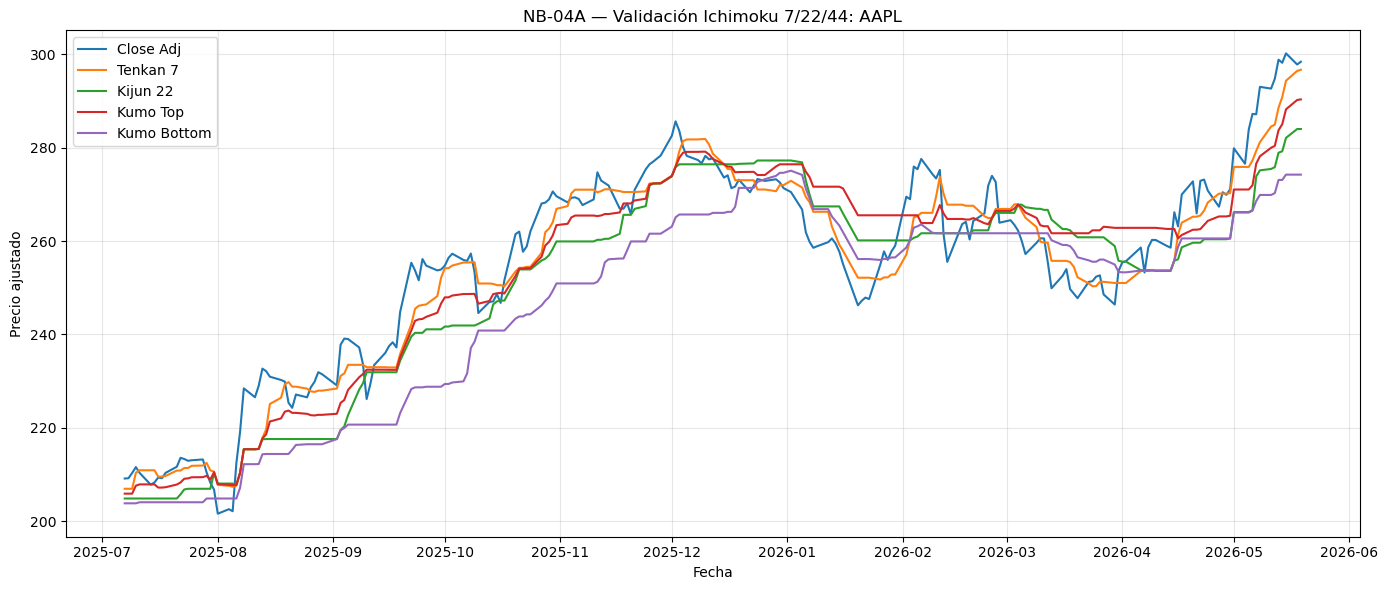

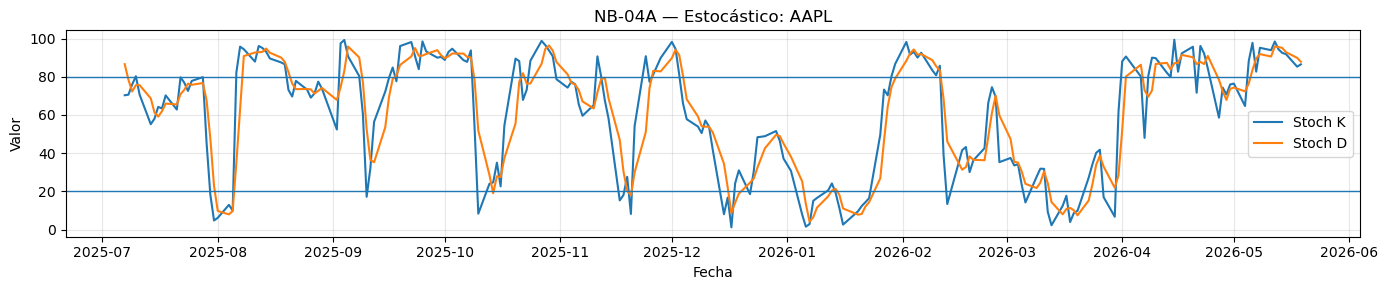

In [8]:
# ============================================================
# 7 — VALIDACIONES VISUALES RÁPIDAS
# ============================================================

import matplotlib.pyplot as plt

# 1) Cobertura por ticker
plt.figure(figsize=(14, 5))
coverage.sort_values("n_rows", ascending=False).set_index("Ticker")["n_rows"].plot(kind="bar")
plt.title("NB-04A — Registros diarios por ticker")
plt.xlabel("Ticker")
plt.ylabel("Nº registros")
plt.xticks([])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Nulos post-warmup
plt.figure(figsize=(12, 5))
nulls_post_warmup.set_index("column")["pct_null_post_warmup"].plot(kind="bar")
plt.title("NB-04A — % nulos post-warmup en columnas críticas")
plt.xlabel("Columna")
plt.ylabel("% nulos")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Vista simple de un ticker de ejemplo
EXAMPLE_TICKER = "AAPL" if "AAPL" in df_indicators["Ticker"].unique() else df_indicators["Ticker"].iloc[0]
example = df_indicators[df_indicators["Ticker"] == EXAMPLE_TICKER].tail(220).copy()

plt.figure(figsize=(14, 6))
plt.plot(example["Date"], example["Close_Adj"], label="Close Adj")
plt.plot(example["Date"], example["Ichimoku_Tenkan"], label="Tenkan 7")
plt.plot(example["Date"], example["Ichimoku_Kijun"], label="Kijun 22")
plt.plot(example["Date"], example["Kumo_Top"], label="Kumo Top")
plt.plot(example["Date"], example["Kumo_Bottom"], label="Kumo Bottom")
plt.title(f"NB-04A — Validación Ichimoku 7/22/44: {EXAMPLE_TICKER}")
plt.xlabel("Fecha")
plt.ylabel("Precio ajustado")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(example["Date"], example["Stoch_K"], label="Stoch K")
plt.plot(example["Date"], example["Stoch_D"], label="Stoch D")
plt.axhline(80, linewidth=1)
plt.axhline(20, linewidth=1)
plt.title(f"NB-04A — Estocástico: {EXAMPLE_TICKER}")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Exportación de resultados

Los siguientes archivos son la salida formal del NB-04A.



```text
outputs_nb04a_sp500_indicators/sp500_indicators_ichimoku_7_22_44.csv
```

```

In [9]:
# ============================================================
# 8 — EXPORTACIÓN
# ============================================================

# Guardar lista de tickers utilizada
pd.DataFrame({"Ticker": sorted(df_indicators["Ticker"].unique())}).to_csv(TICKERS_PATH, index=False)

# Guardar dataset principal
# CSV es más pesado, pero más portable para Jupyter/TFM.
df_indicators.to_csv(INDICATORS_CSV_PATH, index=False)

# Parquet opcional
parquet_saved = False
try:
    df_indicators.to_parquet(INDICATORS_PARQUET_PATH, index=False)
    parquet_saved = True
except Exception as e:
    print("No se pudo guardar parquet. No es crítico. Motivo:", e)

# Guardar auditorías
coverage.to_csv(QUALITY_PATH, index=False)
nulls_post_warmup.to_csv(NULLS_PATH, index=False)

summary_nb04a["parquet_saved"] = parquet_saved
with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary_nb04a, f, indent=2, ensure_ascii=False)

print("Archivos generados")
print("=" * 80)
print("Dataset CSV       :", INDICATORS_CSV_PATH.resolve())
print("Dataset Parquet   :", INDICATORS_PARQUET_PATH.resolve(), "| guardado:", parquet_saved)
print("Tickers utilizados:", TICKERS_PATH.resolve())
print("Quality manifest  :", QUALITY_PATH.resolve())
print("Nulls post-warmup :", NULLS_PATH.resolve())
print("Summary JSON      :", SUMMARY_PATH.resolve())

Archivos generados
Dataset CSV       : /Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators/sp500_indicators_ichimoku_7_22_44.csv
Dataset Parquet   : /Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators/sp500_indicators_ichimoku_7_22_44.parquet | guardado: True
Tickers utilizados: /Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators/sp500_tickers_used.csv
Quality manifest  : /Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators/quality_manifest_nb04a.csv
Nulls post-warmup : /Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators/nulls_post_warmup_nb04a.csv
Summary JSON      : /Users/rbr/TFM_MVP/outputs_nb04a_sp500_indicators/summary_nb04a.json



## Hechos

El NB-04A no toma decisiones de entrada ni de salida. 
Indicadores y variables calculadas correctamente para la siguiente fase:

- Ichimoku adaptado **7/22/44**, no el clásico 9/26/52.
- Tenkan, Kijun, Senkou A, Senkou B y Kumo lógico.
- Variables estructurales: precio sobre Kumo, Kumo alcista, Tenkan sobre Kijun, rupturas de Kumo, cruces Tenkan/Kijun.
- Heiken Ashi y patrones HA2 alcista/bajista.
- SMA5 y pendiente de SMA5.
- Estocástico K/D y cruces.
- RSI, MACD, ATR.
- Volumen relativo y liquidez por dollar volume.
- Flags de warmup y fila operativa.

Punto importante: el notebook calcula Ichimoku con **Kumo lógico sin desplazamiento para la decisión**, y conserva el desplazamiento visual para gráficos. Esto es consistente si el NB-04B usa las columnas lógicas y no las columnas visuales para decidir señales.



## Análisis de calidad de datos



1. **Cobertura completa del universo actual**  
   Los 503 tickers descargados desde Wikipedia tienen datos y al menos una fila operativa. 

2. **Filas operativas suficientes**  
   El 96,61 % de las filas queda marcado como operativo después del warmup. La pérdida esperada se explica por ventanas de cálculo: Ichimoku 44, volumen 20, ATR 14, estocástico 14 y warmup de 70 filas.

3. **Tickers con menor historia**  
   Los tickers con menor porcentaje operativo no son errores necesariamente. La mayoría corresponde a compañías incorporadas recientemente, spin-offs, IPOs o tickers con historial disponible más corto: Q, SNDK, GEV, SOLV, VLTO, KVUE, GEHC, CEG, HOOD, APP, COIN, etc.

4. **Nulos post-warmup bajos**  
   Las únicas columnas críticas con nulos post-warmup relevantes son:
   - `Stoch_D`: 0,2294 %
   - `Stoch_K`: 0,1496 %

   Este nivel de nulos es bajo . 

5. **Liquidez suficiente**  
   Incluso los tickers con menor historia muestran dollar volume medio razonable en la auditoría, por lo que no aparece un problema estructural de liquidez en el universo descargado.
